In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Import all algorithms for exploration
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import seaborn as sns

from imblearn.pipeline import Pipeline

import os
import mlflow
import mlflow.sklearn
import joblib
import warnings

warnings.filterwarnings('ignore')


In [27]:
df = pd.read_csv("C:\\Users\\Kolade\\Desktop\\DayFigurez internship\\Datasets\\market_pipe_thickness_loss_dataset.csv")
df.head()

,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,ASTM A333 Grade 6,300,84.9,16.04,4.91,31.72,2,Moderate
1,800,22.00,PVC,ASTM A106 Grade B,150,14.1,7.38,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,API 5L X52,2500,0.6,2.12,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,API 5L X42,1500,52.7,5.58,6.20,16.01,19,Critical
4,1500,24.32,HDPE,API 5L X65,1500,11.7,12.29,8.58,35.28,20,Critical


In [28]:
df_2 = pd.read_csv("C:\\Users\\Kolade\\Desktop\\DayFigurez internship\\Datasets\\pipeline_dataset.csv")
df_2.head()

,sensor_id,distance_from_start,pressure_level,leak_size,leak_position,feature_1,feature_2,feature_3,feature_4,feature_5,...,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21
0,0,0.0,70,1,85.626577,-120.759630,2.062890,3.898424,0.851203,-3.127682,...,5.575276,8.078702,0.030260,0.115834,0.171513,0.213360,-0.040152,10537.713222,6577.321733,0.330682
1,1,10.0,70,1,85.626577,-120.005936,3.026479,4.304101,1.207732,-3.353982,...,6.154081,8.835816,0.126207,0.170342,0.191786,0.090301,-0.065469,10427.476866,6621.943197,0.280691
2,2,20.0,70,1,85.626577,-120.116130,4.078403,5.522919,1.135423,-4.062794,...,7.247250,9.668743,0.116893,0.235233,0.284628,0.147933,-0.026910,10312.854285,6673.189308,0.230147
3,3,30.0,70,1,85.626577,-118.604348,4.687656,5.537389,1.066426,-4.293335,...,7.086577,10.399059,0.160559,0.203719,0.309128,0.142018,-0.076868,10177.593170,6738.297837,0.187218
4,4,40.0,70,1,85.626577,-117.599927,6.152464,6.763119,0.979795,-5.408795,...,7.336065,10.592782,0.171335,0.445095,0.333123,0.155949,-0.039346,10000.186635,6792.711082,0.146247


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pipe_Size_mm              1000 non-null   int64  
 1   Thickness_mm              1000 non-null   float64
 2   Material                  1000 non-null   object 
 3   Grade                     1000 non-null   object 
 4   Max_Pressure_psi          1000 non-null   int64  
 5   Temperature_C             1000 non-null   float64
 6   Corrosion_Impact_Percent  1000 non-null   float64
 7   Thickness_Loss_mm         1000 non-null   float64
 8   Material_Loss_Percent     1000 non-null   float64
 9   Time_Years                1000 non-null   int64  
 10  Condition                 1000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 86.1+ KB


In [30]:
df.describe()

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,522.000000,16.073530,1004.100000,42.595600,9.745990,4.886300,46.747560,12.961000
std,443.703587,10.548358,812.843099,41.127071,5.817492,2.901123,46.602553,7.135993
min,50.000000,3.000000,150.000000,-50.000000,0.000000,0.010000,0.080000,1.000000
25%,150.000000,7.357500,300.000000,13.400000,4.492500,2.365000,15.665000,7.000000
50%,300.000000,12.930000,900.000000,41.200000,9.720000,4.915000,31.660000,13.000000
75%,800.000000,23.027500,1500.000000,69.150000,14.832500,7.432500,61.035000,19.000000
max,1500.000000,49.530000,2500.000000,149.700000,20.000000,9.990000,318.750000,25.000000


In [31]:
df['Condition'].unique()
# , 'Grade', 'Condition']

array(['Moderate', 'Critical', 'Normal'], dtype=object)

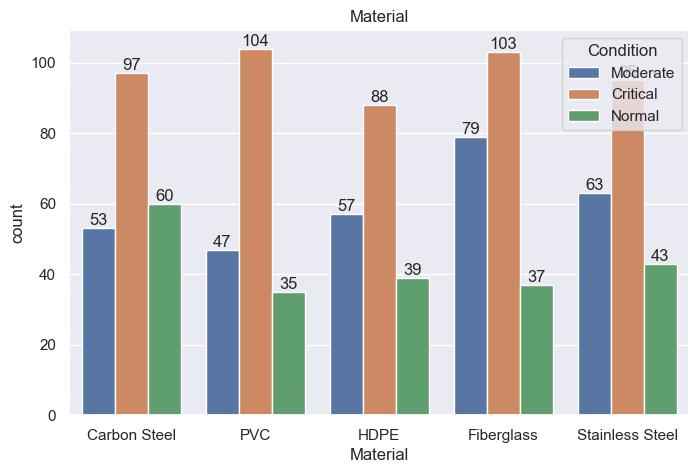

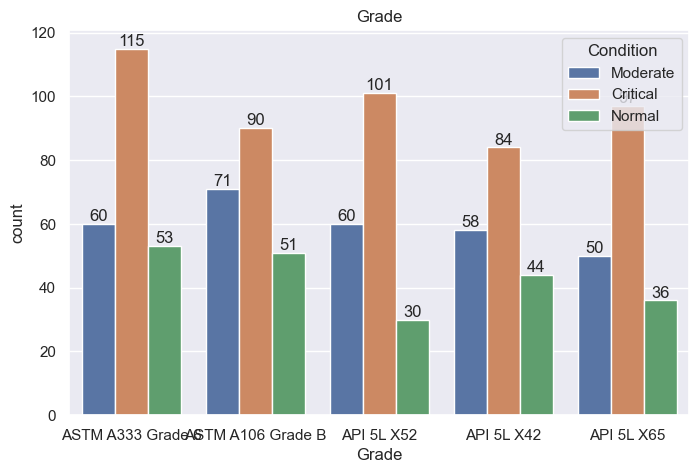

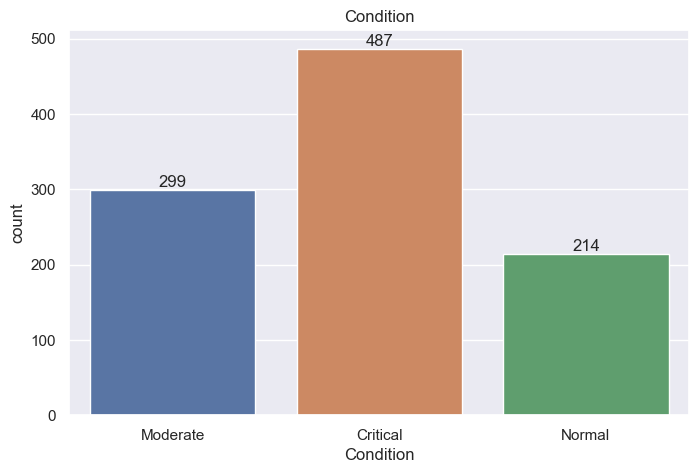

In [7]:
categories = ['Material', 'Grade', 'Condition']

sns.set(rc={'figure.figsize':(8,5)})

for c in categories:

    ax = sns.countplot(x=c, data=df, hue='Condition')
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(c)
    plt.show()

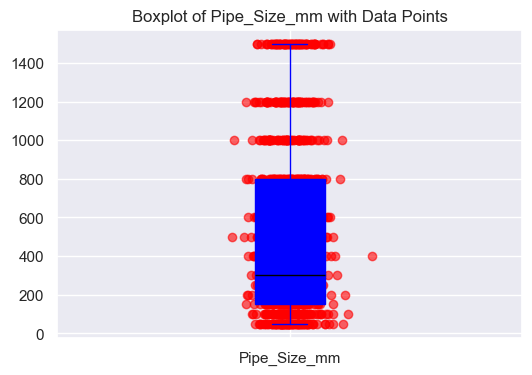

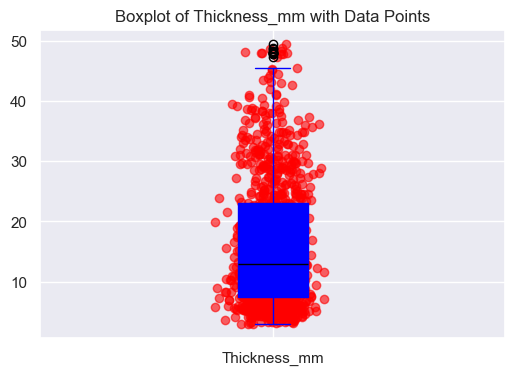

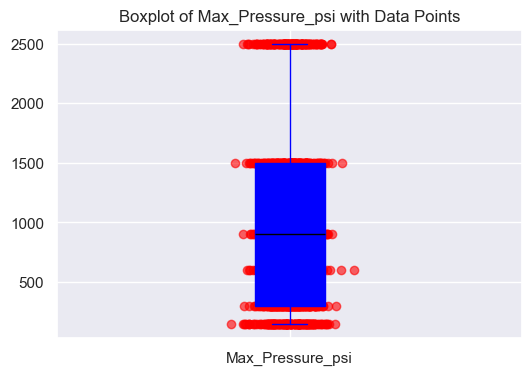

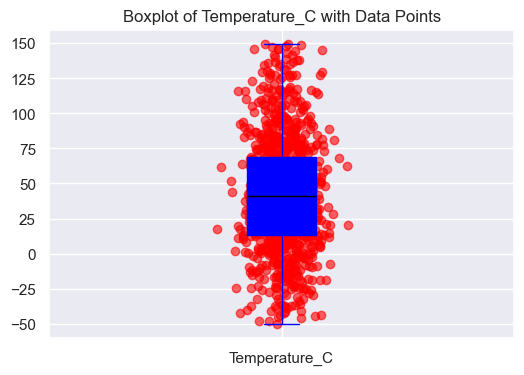

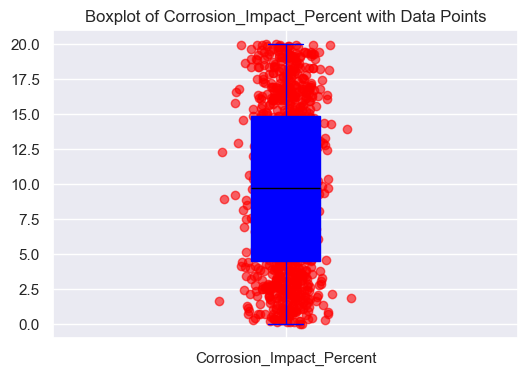

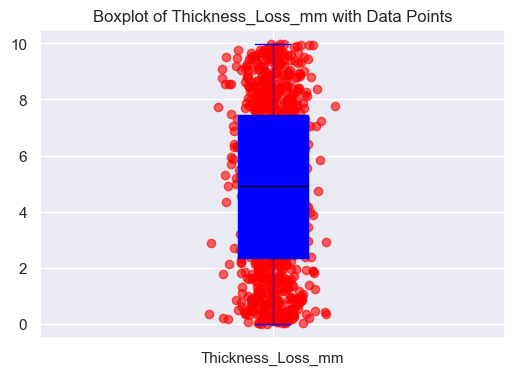

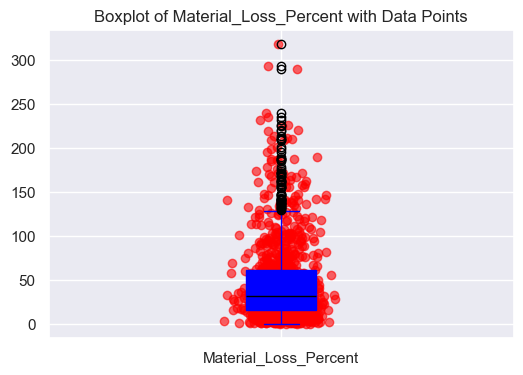

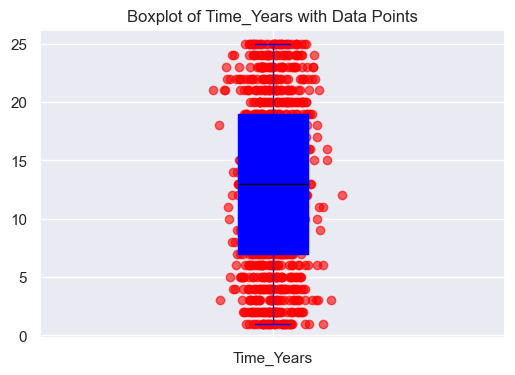

In [8]:
cols = ['Pipe_Size_mm', 'Thickness_mm', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm', 'Material_Loss_Percent', 'Time_Years']

for col in cols:
    plt.figure(figsize=(6, 4))

    plt.boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor='blue', color='blue'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='blue'),
        capprops=dict(color='blue')
    )

    x = np.random.normal(1, 0.04, size=len(df[col]))
    plt.scatter(x, df[col], color='red', alpha=0.6)

    plt.title(f"Boxplot of {col} with Data Points")
    plt.xticks([1], [col])

    plt.show()


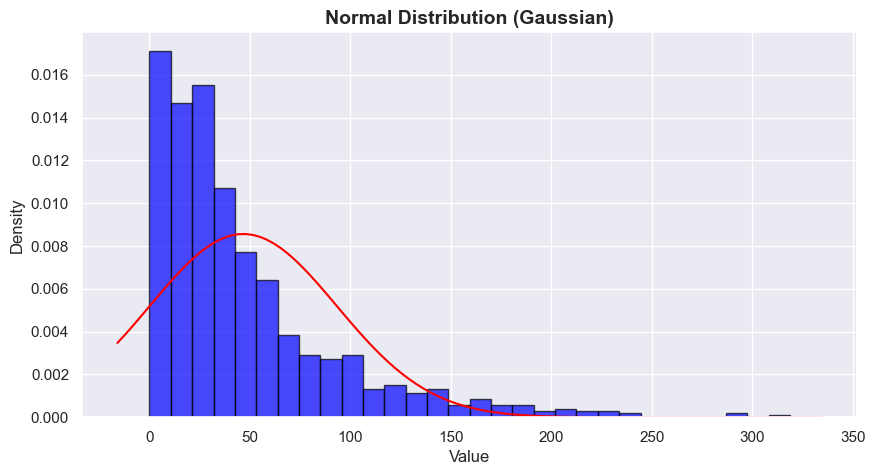

In [9]:
from scipy.stats import norm

# normal_data = np.random.normal(loc=100, scale=15, size=1000)
# 'Pipe_Size_mm', 'Thickness_mm', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm', 'Material_Loss_Percent', 'Time_Years'
# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(df["Material_Loss_Percent"], bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')

mu, std = norm.fit(df["Material_Loss_Percent"])

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mu, std)

plt.plot(x, p, color='red')

plt.title('Normal Distribution (Gaussian)', fontsize=14, fontweight='bold')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

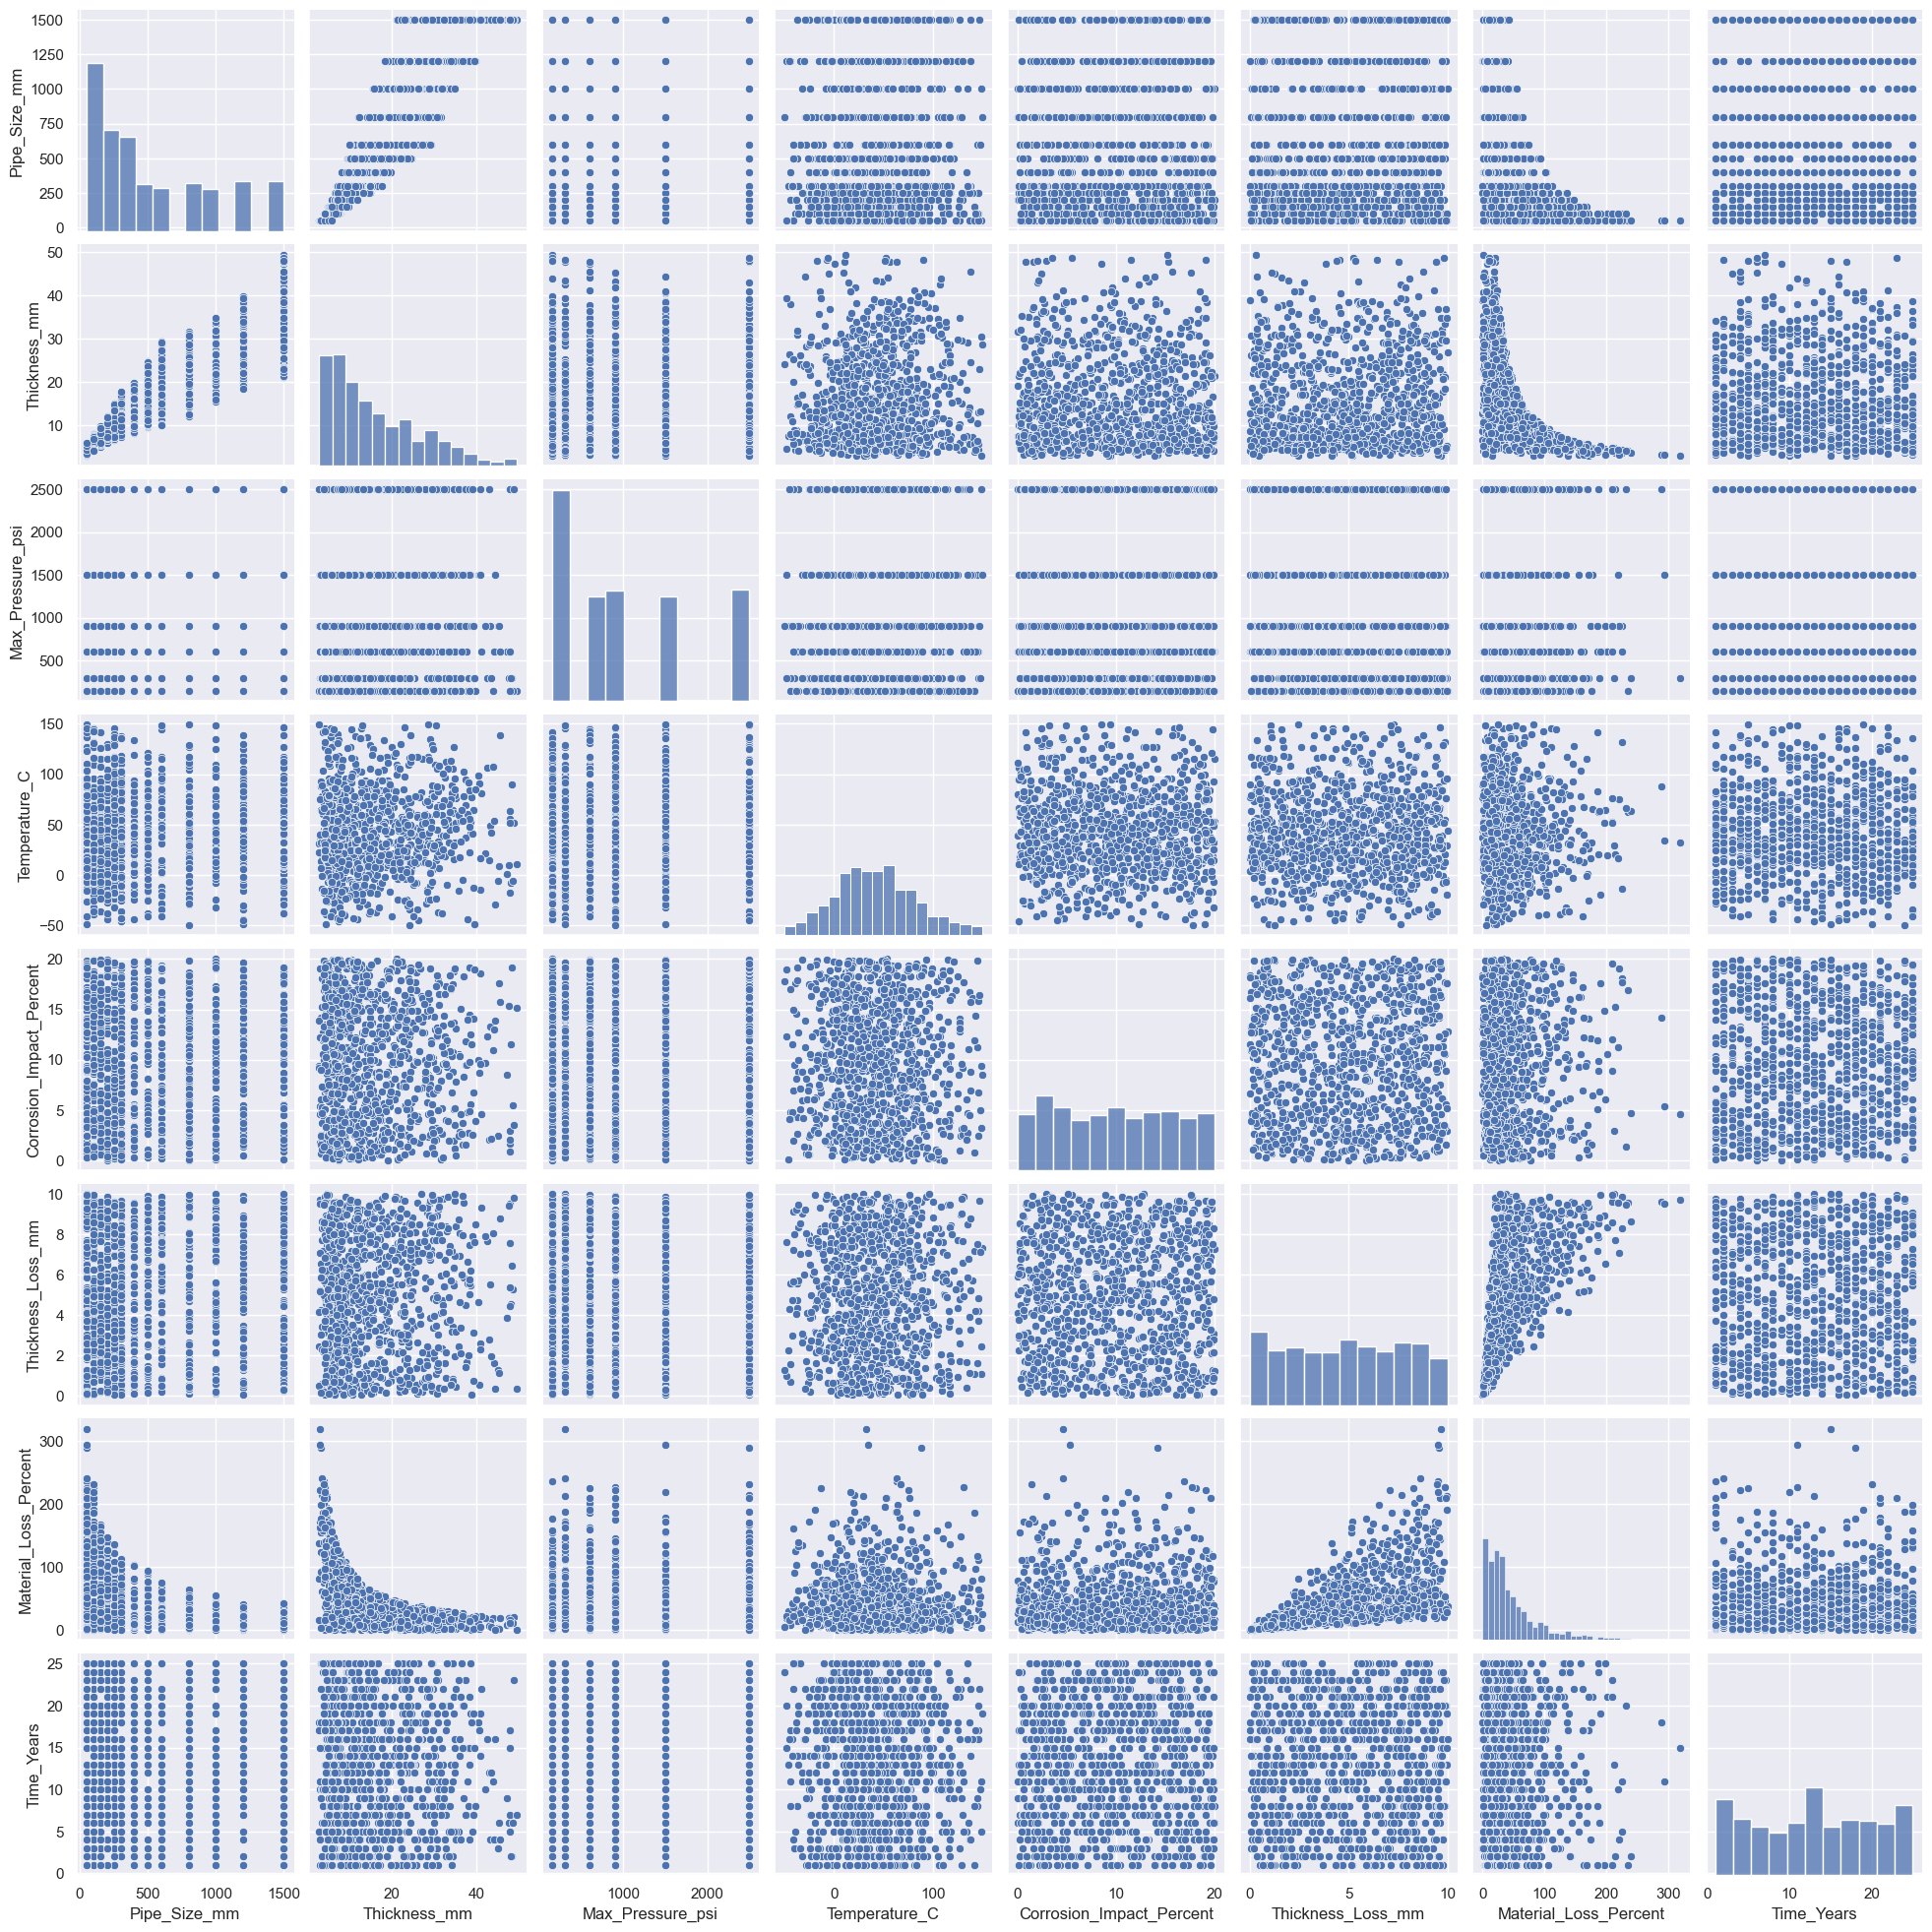

In [10]:
g = sns.pairplot(df.select_dtypes(include='number'))


In [11]:
# Thickness_mm, Pipe_Size_mm, Material_Loss_Percent
# Apply boxcox on some columns and check the distribution again
# from scipy.stats import boxcox
# Remove the ones I dont need
# You decide x and y
# split it and Scale it
# First do one model, then check, then run grid searchcv
# Then do cross validation and check the metrics
# do mlflow
# save the model, then do the same for the rest of the models, then compare the results and pick the best one
# Streamlit


In [ ]:
# from scipy.stats import boxcox

# df['material_loss_boxcox'], lam = boxcox(df['Material_Loss_Percent'])
# df['Pipe_Size_mm_boxcox'], lam = boxcox(df['Pipe_Size_mm'])
# df['Thickness_mm_boxcox'], lam = boxcox(df['Thickness_mm'])


In [11]:
# normal_data = np.random.normal(loc=100, scale=15, size=1000)
# 'Pipe_Size_mm', 'Thickness_mm', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm', 'Material_Loss_Percent', 'Time_Years'
# Plot histogram
# plt.figure(figsize=(10, 5))
# plt.hist(df["Thickness_mm_boxcox"], bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')

# mu, std = norm.fit(df["Thickness_mm_boxcox"])

# xmin, xmax = plt.xlim()
# x = np.linspace(xmin, xmax, 100)

# p = norm.pdf(x, mu, std)

# plt.plot(x, p, color='red')

# plt.title('Normal Distribution (Gaussian)', fontsize=14, fontweight='bold')
# plt.xlabel('Value')
# plt.ylabel('Density')
# plt.show()

In [32]:
df.head()

,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,ASTM A333 Grade 6,300,84.9,16.04,4.91,31.72,2,Moderate
1,800,22.00,PVC,ASTM A106 Grade B,150,14.1,7.38,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,API 5L X52,2500,0.6,2.12,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,API 5L X42,1500,52.7,5.58,6.20,16.01,19,Critical
4,1500,24.32,HDPE,API 5L X65,1500,11.7,12.29,8.58,35.28,20,Critical


In [33]:
# df = df.drop(columns=['Material_Loss_Percent', 'Pipe_Size_mm', 'Thickness_mm'])

In [34]:
final_df = pd.get_dummies(df, columns =['Grade', 'Material'])
final_df.head()

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition,Grade_API 5L X42,Grade_API 5L X52,Grade_API 5L X65,Grade_ASTM A106 Grade B,Grade_ASTM A333 Grade 6,Material_Carbon Steel,Material_Fiberglass,Material_HDPE,Material_PVC,Material_Stainless Steel
0,800,15.48,300,84.9,16.04,4.91,31.72,2,Moderate,False,False,False,False,True,True,False,False,False,False
1,800,22.00,150,14.1,7.38,7.32,33.27,4,Critical,False,False,False,True,False,False,False,False,True,False
2,400,12.05,2500,0.6,2.12,6.32,52.45,7,Critical,False,True,False,False,False,True,False,False,False,False
3,1500,38.72,1500,52.7,5.58,6.20,16.01,19,Critical,True,False,False,False,False,True,False,False,False,False
4,1500,24.32,1500,11.7,12.29,8.58,35.28,20,Critical,False,False,True,False,False,False,False,True,False,False


In [35]:
final_df.columns

Index(['Pipe_Size_mm', 'Thickness_mm', 'Max_Pressure_psi', 'Temperature_C',
       'Corrosion_Impact_Percent', 'Thickness_Loss_mm',
       'Material_Loss_Percent', 'Time_Years', 'Condition', 'Grade_API 5L X42',
       'Grade_API 5L X52', 'Grade_API 5L X65', 'Grade_ASTM A106 Grade B',
       'Grade_ASTM A333 Grade 6', 'Material_Carbon Steel',
       'Material_Fiberglass', 'Material_HDPE', 'Material_PVC',
       'Material_Stainless Steel'],
      dtype='object')

In [60]:
x = final_df.drop(columns=['Condition'])
y = final_df['Condition']

In [61]:
lr_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
lr_model.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
final_fi2 = pd.DataFrame()

for i, column in enumerate(final_df.drop('Condition', axis = 1)):
    
    print(f"{column}: {lr_model.feature_importances_[i]:.3f}")

    fi = pd.DataFrame({'Feature': [column], 'Importance Score': [lr_model.feature_importances_[i]]})
    
    try:
        final_fi2 = pd.concat([final_fi2, fi], ignore_index=True)
    except:
        final_fi2 = fi
    
final_fi2 = final_fi2.sort_values('Importance Score', ascending=False)
final_fi2

Pipe_Size_mm: 0.024
Thickness_mm: 0.044
Max_Pressure_psi: 0.010
Temperature_C: 0.020
Corrosion_Impact_Percent: 0.021
Thickness_Loss_mm: 0.611
Material_Loss_Percent: 0.229
Time_Years: 0.017
Grade_API 5L X42: 0.003
Grade_API 5L X52: 0.003
Grade_API 5L X65: 0.002
Grade_ASTM A106 Grade B: 0.002
Grade_ASTM A333 Grade 6: 0.002
Material_Carbon Steel: 0.004
Material_Fiberglass: 0.002
Material_HDPE: 0.002
Material_PVC: 0.002
Material_Stainless Steel: 0.002


,Feature,Importance Score
5,Thickness_Loss_mm,0.610608
6,Material_Loss_Percent,0.228952
1,Thickness_mm,0.044264
0,Pipe_Size_mm,0.024395
4,Corrosion_Impact_Percent,0.020914
3,Temperature_C,0.019658
7,Time_Years,0.016962
2,Max_Pressure_psi,0.010201
13,Material_Carbon Steel,0.003625
9,Grade_API 5L X52,0.003221


In [39]:
x_train, x_test, y_train, y_test =train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f'Size of train independent data is : {x_train.shape} to {y_train.shape[0]} of dependent data')
print(f'Size of test independent data is {x_test.shape} to {y_test.shape[0]} of dependent data')

Size of train independent data is : (800, 18) to 800 of dependent data
Size of test independent data is (200, 18) to 200 of dependent data


In [40]:
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.fit_transform(x_test)

In [41]:
from xgboost import XGBClassifier

algorithms = {
    "Logistic_Regression": {
        "model": LogisticRegression(random_state=42, max_iter=10000),
        "params": {'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'distance'],'penalty': ['l1', 'l2']}
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    "SVC": {
        "model": SVC(random_state=42),
        "params": {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': [None, 'balanced']}
    },
    "Random_Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'class_weight': [None, 'balanced'], 'min_samples_leaf': [1, 2, 4]}
    },
    # "XGBoost": {
    #     "model": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    #     "params": {
    #         'n_estimators': [50, 100],
    #         'max_depth': [3, 5, 7],
    #         'learning_rate': [0.05, 0.1],
    #         'subsample': [0.8, 1.0],
    #         'colsample_bytree': [0.8, 1.0],
    #         'gamma': [0, 1]
    #     }
    # },
    "Decision_Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {'criterion': ['gini', 'entropy'], 'class_weight': [None, 'balanced'], 'max_depth': [5, 10, 20]}
    }
}

champion_name = ""
champion_model = None
champion_accuracy = 0.0

print("Starting Algorithm Exploration...\n" + "-"*40)

Starting Algorithm Exploration...
----------------------------------------


In [42]:
# os.makedirs("mlruns", exist_ok=True)

# mlflow.set_tracking_uri("sqlite:///mlruns/mlflow.db")
# mlflow.set_experiment("Pipleline_classification_Exploration")
# for algo_name, config in algorithms.items():
#     with mlflow.start_run(run_name=f"Tuning_{algo_name}"):
#         print(f"Training and tuning {algo_name}...")
        
#         # Initialize GridSearchCV
#         grid_search = GridSearchCV(
#             estimator=config["model"], 
#             param_grid=config["params"], 
#             cv=5, 
#             n_jobs=-1, 
#             scoring='accuracy'
#         )
        
#         # Fit the model
#         grid_search.fit(x_train_scaled, y_train)
        
#         # Extract best model and parameters for this specific algorithm
#         best_model_for_algo = grid_search.best_estimator_
#         best_params_for_algo = grid_search.best_params_
        
#         # Evaluate on the test set
#         y_pred = best_model_for_algo.predict(x_test_scaled)
#         test_accuracy = accuracy_score(y_test, y_pred)
        
#         # Log to MLflow
#         mlflow.log_params(best_params_for_algo)
#         mlflow.log_metric("test_accuracy", test_accuracy)
#         mlflow.sklearn.log_model(best_model_for_algo, f"{algo_name}_model")
        
#         print(f"[{algo_name}] Best Params: {best_params_for_algo}")
#         print(f"[{algo_name}] Test Accuracy: {test_accuracy * 100:.2f}%\n")
        
#         # Check if this is the best model overall
#         if test_accuracy > champion_accuracy:
#             champion_accuracy = test_accuracy
#             champion_model = best_model_for_algo
#             champion_name = algo_name

# print("-" * 40)
# print(f"🏆 CHAMPION MODEL: {champion_name} with {champion_accuracy * 100:.2f}% accuracy!")

In [44]:
from sklearn.compose import ColumnTransformer

boxcox_cols = ['Material_Loss_Percent', 'Pipe_Size_mm', 'Thickness_mm']

# preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ('boxcox', PowerTransformer(method='box-cox'), boxcox_cols)
    ],
    remainder='passthrough'
)

# full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, class_weight=None, max_depth=None, min_samples_leaf=4, n_estimators=100))
])

# train
pipeline.fit(x_train, y_train)


,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('boxcox', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The gi

In [45]:
# [Random_Forest]  {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}
# [Random_Forest] Test Accuracy: 98.00%

# model = RandomForestClassifier(random_state=42, class_weight=None, max_depth=None, min_samples_leaf=4, n_estimators=100)
# model.fit(x_train_scaled, y_train)


In [46]:
y_pred_1 = pipeline.predict(x_train)
y_pred_2 = pipeline.predict(x_test)

In [47]:
print(classification_report(y_train, y_pred_1))
print(classification_report(y_test, y_pred_2))


              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       390
    Moderate       1.00      1.00      1.00       239
      Normal       1.00      1.00      1.00       171

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00        97
    Moderate       0.98      1.00      0.99        60
      Normal       1.00      0.98      0.99        43

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [48]:
y_pred_2

array(['Normal', 'Critical', 'Normal', 'Normal', 'Normal', 'Moderate',
       'Critical', 'Moderate', 'Normal', 'Moderate', 'Moderate', 'Normal',
       'Critical', 'Critical', 'Moderate', 'Critical', 'Moderate',
       'Critical', 'Moderate', 'Moderate', 'Normal', 'Critical',
       'Critical', 'Critical', 'Critical', 'Moderate', 'Critical',
       'Normal', 'Critical', 'Critical', 'Normal', 'Critical', 'Normal',
       'Critical', 'Moderate', 'Critical', 'Critical', 'Normal',
       'Critical', 'Normal', 'Moderate', 'Moderate', 'Moderate',
       'Critical', 'Moderate', 'Critical', 'Critical', 'Moderate',
       'Moderate', 'Critical', 'Critical', 'Critical', 'Normal',
       'Critical', 'Normal', 'Critical', 'Critical', 'Moderate', 'Normal',
       'Critical', 'Critical', 'Moderate', 'Critical', 'Moderate',
       'Critical', 'Normal', 'Critical', 'Critical', 'Critical',
       'Critical', 'Critical', 'Moderate', 'Moderate', 'Normal', 'Normal',
       'Critical', 'Critical', 'Modera

In [49]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_2
})

comparison['Correct'] = comparison['Actual'] == comparison['Predicted']

print(comparison.head())

       Actual Predicted  Correct
550    Normal    Normal     True
998  Critical  Critical     True
195    Normal    Normal     True
865    Normal    Normal     True
208    Normal    Normal     True


In [50]:
wrong = comparison[comparison['Correct'] == False]

print(wrong)

     Actual Predicted  Correct
512  Normal  Moderate    False


In [51]:
model_filename = 'pipeline_model2.pkl'
# scaler_filename = 'standard_scaler.pkl'

# Dump artifacts to disk
joblib.dump(pipeline, model_filename)
# joblib.dump(scaler, scaler_filename)

['pipeline_model2.pkl']

In [53]:
# Cross validation
from sklearn.model_selection import cross_val_score


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, x_train, y_train, cv=cv, scoring='accuracy')

print("="*50)
print("5-FOLD CROSS-VALIDATION")
print("="*50)
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"\nInterpretation: Model performance is {'STABLE' if cv_scores.std() < 0.05 else 'VARIABLE'} across folds")

5-FOLD CROSS-VALIDATION
Fold 1: 1.0000
Fold 2: 0.9938
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000

Mean: 0.9988
Std Dev: 0.0025

Interpretation: Model performance is STABLE across folds


In [54]:
df.corr(numeric_only=True)

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years
Pipe_Size_mm,1.000000,0.907295,0.005314,0.033515,-0.029507,0.063189,-0.486962,-0.038725
Thickness_mm,0.907295,1.000000,0.031811,0.035808,-0.035593,0.049979,-0.535069,-0.054131
Max_Pressure_psi,0.005314,0.031811,1.000000,0.011480,-0.024628,0.026025,0.007957,0.061999
Temperature_C,0.033515,0.035808,0.011480,1.000000,-0.012171,0.010826,0.004227,-0.024172
Corrosion_Impact_Percent,-0.029507,-0.035593,-0.024628,-0.012171,1.000000,0.008548,0.026738,-0.024244
Thickness_Loss_mm,0.063189,0.049979,0.026025,0.010826,0.008548,1.000000,0.576865,-0.012600
Material_Loss_Percent,-0.486962,-0.535069,0.007957,0.004227,0.026738,0.576865,1.000000,0.006085
Time_Years,-0.038725,-0.054131,0.061999,-0.024172,-0.024244,-0.012600,0.006085,1.000000


### Application Deployment with Streamlit

In [ ]:
import streamlit as st

def get_user_input():
    pipe_size = st.sidebar.number_input("Enter Pipe Size (mm): ", min_value=0, value=1000)
    thickness = st.sidebar.number_input("Enter Thickness (mm): ", min_value=0.0, value=20.0)
    max_pressure = st.sidebar.number_input("Enter Maximum Pressure (psi): ", min_value=0, value=1500)
    temperature = st.sidebar.number_input("Enter Temperature (°C): ", min_value=0.0, value=60.0)
    corrosion_impact = st.sidebar.number_input("Enter Number of Corrosion Impact (%): ", min_value=0.0, max_value=100.0, value=16.0)
    # Use slider
    thickness_loss = st.sidebar.number_input("Enter Thickness Loss (mm): ", min_value=0.0, value=5.0)
    material_loss = st.sidebar.number_input("Enter Material Loss (%): ", min_value=0.0, value=60.0)
    # Use slider
    time = st.sidebar.number_input("Enter Time (years): ", min_value=0, value=10)

    material = st.sidebar.selectbox('Enter Material',['Carbon Steel', 'PVC', 'HDPE', 'Fiberglass', 'Stainless Steel'])
    grade = st.sidebar.selectbox('Enter Grade',['ASTM A333 Grade 6', 'ASTM A106 Grade B', 'API 5L X52',
       'API 5L X42', 'API 5L X65'])
    
    user_data = {
        'Pipe_Size_mm': pipe_size,
        'Thickness_mm': thickness,
        f'Material_{material}': 1,
        f'Grade_{grade}': 1,
        'Max_Pressure_psi': max_pressure,
        'Temperature_C': temperature,
        'Corrosion_Impact_Percent': corrosion_impact,
        'Thickness_Loss_mm': thickness_loss,
        'Material_Loss_Percent': material_loss,
        'Time_Years': time
    }

    return user_data

user_data = get_user_input()
user_data

In [ ]:
def prepare_input(data, feature_list):
    input_data = {feature: data.get(feature, 0) for feature in feature_list}
    return np.array([list(input_data.values())])

features = [
    'Pipe_Size_mm',
    'Thickness_mm',
    'Material_Carbon Steel',
    'Material_Fiberglass', 
    'Material_HDPE', 
    'Material_PVC',
    'Material_Stainless Steel',
    'Grade_ASTM A333 Grade 6',
    'Grade_ASTM A106 Grade B', 
    'Grade_API 5L X52', 
    'Grade_API 5L X42',
    'Grade_API 5L X65',
    'Max_Pressure_psi', 
    'Temperature_C', 
    'Corrosion_Impact_Percent',
    'Thickness_Loss_mm',
    'Time_Years'
]

input_array = prepare_input(user_data, features)
input_array

array(['ASTM A333 Grade 6', 'ASTM A106 Grade B', 'API 5L X52',
       'API 5L X42', 'API 5L X65'], dtype=object)

In [ ]:
prediction = pipeline.predict(input_array)
prediction

In [ ]:
import plotly.express as px

final_fi_sorted = final_fi2.sort_values('Importance Score', ascending=True)

fig = px.bar(
    final_fi_sorted,
    x='Importance Score',
    y='Feature',
    orientation='h',
    title = 'Feature Importance Scores from Linear Regression Model',
    labels={'Importance Score': 'Importance', 'Feature': 'Feature'},
    text='Importance Score',
    # color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    xaxis_title='Importance Score',
    yaxis_title='Feature',
    template='plotly_white',
    height=500,
    yaxis=dict(tickmode='linear'),
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
)

fig.show()

In [65]:
final_fi2['Importance Score'] = final_fi2['Importance Score'].round(3)
final_fi2 = final_fi2.head(16)
final_fi2.to_excel('feature_importance_pipe.xlsx')

In [63]:
final_fi2.head()

,Feature,Importance Score
5,Thickness_Loss_mm,0.610608
6,Material_Loss_Percent,0.228952
1,Thickness_mm,0.044264
0,Pipe_Size_mm,0.024395
4,Corrosion_Impact_Percent,0.020914


In [66]:
final_df.head()

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition,Grade_API 5L X42,Grade_API 5L X52,Grade_API 5L X65,Grade_ASTM A106 Grade B,Grade_ASTM A333 Grade 6,Material_Carbon Steel,Material_Fiberglass,Material_HDPE,Material_PVC,Material_Stainless Steel
0,800,15.48,300,84.9,16.04,4.91,31.72,2,Moderate,False,False,False,False,True,True,False,False,False,False
1,800,22.00,150,14.1,7.38,7.32,33.27,4,Critical,False,False,False,True,False,False,False,False,True,False
2,400,12.05,2500,0.6,2.12,6.32,52.45,7,Critical,False,True,False,False,False,True,False,False,False,False
3,1500,38.72,1500,52.7,5.58,6.20,16.01,19,Critical,True,False,False,False,False,True,False,False,False,False
4,1500,24.32,1500,11.7,12.29,8.58,35.28,20,Critical,False,False,True,False,False,False,False,True,False,False
